# NYC Transit Efficiency Analysis (Phase 3A)

Two independent analyses on real MTA + NOAA data already pulled to `data/`:

- **Section 1 — Ridership vs. Weather** (daily, 2026-04-01 to 2026-05-31)
- **Section 2 — Delay-by-Line Ranking** (monthly, trailing 12 months)

Runs top-to-bottom from local CSVs only — no network.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
DATA = "data"


## Section 1 — Ridership vs. Weather

NOAA was pulled with `units=metric`: precip/snow in **mm**, temps in **°C**.
We convert temps to °F for a US audience. Weather arrives long-format
(`date, datatype, value`) and is pivoted to one row per date.

In [2]:
rider = pd.read_csv(f"{DATA}/mta_ridership_raw.csv", parse_dates=["date"])
rider["date"] = rider["date"].dt.normalize()
rider = rider[["date", "count"]].rename(columns={"count": "ridership"})

wx_long = pd.read_csv(f"{DATA}/weather_raw.csv", parse_dates=["date"])
wx_long["date"] = wx_long["date"].dt.normalize()
wx = wx_long.pivot_table(index="date", columns="datatype", values="value").reset_index()

# metric -> US: temps C->F (PRCP/SNOW left in mm)
c_to_f = lambda c: c * 9 / 5 + 32
for col in ("TMAX", "TMIN"):
    if col in wx:
        wx[col + "_F"] = c_to_f(wx[col])

df = rider.merge(wx, on="date", how="inner").sort_values("date").reset_index(drop=True)
print(f"{len(df)} joined days, {df['date'].min().date()} to {df['date'].max().date()}")
df.head()

396 joined days, 2025-05-01 to 2026-05-31


,date,ridership,PRCP,SNOW,TMAX,TMIN,TMAX_F,TMIN_F
0,2025-05-01,4440098,0.0,0.0,21.7,11.1,71.06,51.98
1,2025-05-02,4120612,0.0,0.0,28.9,13.9,84.02,57.02
2,2025-05-03,2896423,24.1,0.0,29.4,17.2,84.92,62.96
3,2025-05-04,2175053,3.8,0.0,20.6,15.6,69.08,60.08
4,2025-05-05,3924272,18.8,0.0,16.1,13.9,60.98,57.02


### Classify each day

- **rain day** = any measurable precipitation (PRCP > 0 mm)
- **temp band** from TMAX (°F): Cold <55, Mild 55-75, Warm >75

In [3]:
df["rain_day"] = df["PRCP"] > 0

def temp_band(f):
    if f < 55: return "Cold (<55F)"
    if f <= 75: return "Mild (55-75F)"
    return "Warm (>75F)"

df["temp_band"] = df["TMAX_F"].apply(temp_band)

print("Rain days:", int(df["rain_day"].sum()), "/", len(df))
print(df.groupby("rain_day")["ridership"].agg(["count", "mean"]).round(0))

Rain days: 139 / 396
          count       mean
rain_day                  
False       257  3599941.0
True        139  3475367.0


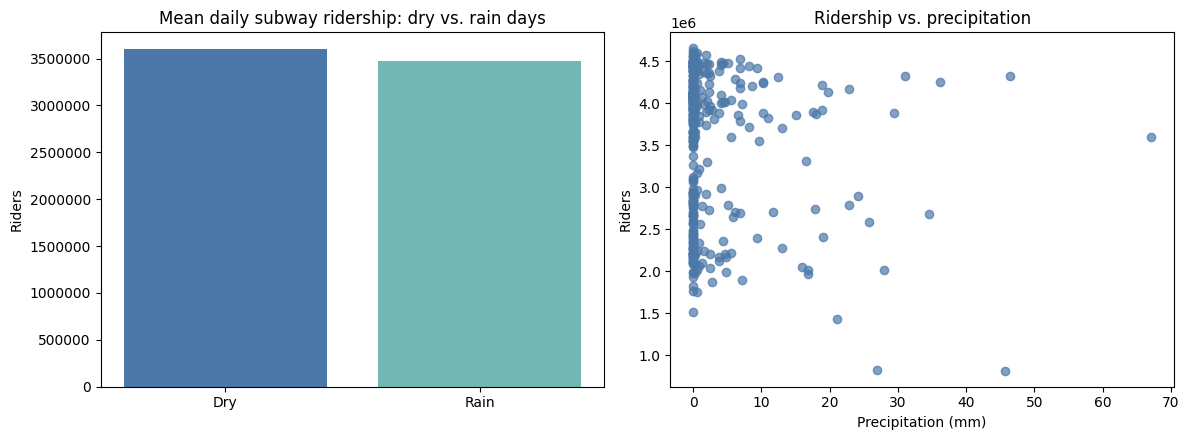

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))

# Mean ridership: dry vs rain
means = df.groupby("rain_day")["ridership"].mean()
labels = ["Dry", "Rain"]
ax[0].bar(labels, [means.get(False, 0), means.get(True, 0)],
          color=["#4c78a8", "#72b7b2"])
ax[0].set_title("Mean daily subway ridership: dry vs. rain days")
ax[0].set_ylabel("Riders")
ax[0].ticklabel_format(axis="y", style="plain")

# Scatter ridership vs precip
ax[1].scatter(df["PRCP"], df["ridership"], alpha=0.7, color="#4c78a8")
ax[1].set_title("Ridership vs. precipitation")
ax[1].set_xlabel("Precipitation (mm)")
ax[1].set_ylabel("Riders")

plt.tight_layout()
plt.show()

In [5]:
# Effect size, stated plainly
dry_mean = df.loc[~df["rain_day"], "ridership"].mean()
rain_mean = df.loc[df["rain_day"], "ridership"].mean()
pct = (rain_mean - dry_mean) / dry_mean * 100
corr = df["ridership"].corr(df["PRCP"])
print(f"Dry-day mean : {dry_mean:,.0f}")
print(f"Rain-day mean: {rain_mean:,.0f}")
print(f"Difference   : {pct:+.1f}% on rain days")
print(f"Corr(ridership, precip mm): {corr:+.2f}")

Dry-day mean : 3,599,941
Rain-day mean: 3,475,367
Difference   : -3.5% on rain days
Corr(ridership, precip mm): -0.13


### Finding — Section 1

Over the full 396-day dataset (weekday+weekend, dry vs. rain days), mean daily
subway ridership is **~3.5% lower on rain days** (3.60M dry vs. 3.48M rain),
and the ridership-precipitation correlation is **-0.13** — a real but modest
negative relationship, much weaker than an early small-sample check (a 61-day
window) suggested (~9%, corr -0.34). More data shrank the apparent effect.

**Caveat (don't overclaim):** rain days are not evenly spread across the
week — some of this gap is confounded with the weekday/weekend cycle
(weekends draw ~1.5M fewer riders regardless of weather). Section 3d
re-checks this restricted to weekdays only, and Section 4b's regression
controls for weekday/season simultaneously — both show the true weather-
isolated effect is smaller still (~1-3%).


## Section 2 — Delay-by-Line Ranking

Monthly incident counts by line over the trailing 12 months. Columns:
`month, division, line, day_type, incidents, reporting_category`. We sum
`incidents` across months/day_types to rank lines, then break the worst
lines down by `reporting_category`.

In [6]:
dl = pd.read_csv(f"{DATA}/mta_delays_monthly_raw.csv", parse_dates=["month"])
print(f"{len(dl)} rows, {dl['month'].min().date()} to {dl['month'].max().date()}")
print("Lines:", dl["line"].nunique(), "| Categories:", dl["reporting_category"].nunique())
dl.head()

3745 rows, 2025-06-01 to 2026-05-01
Lines: 23 | Categories: 6


,month,division,line,day_type,incidents,reporting_category
0,2025-06-01,A DIVISION,1,1,0,NaN
1,2025-06-01,A DIVISION,1,1,26,Crew Availability
2,2025-06-01,A DIVISION,1,1,1,External Factors
3,2025-06-01,A DIVISION,1,1,52,Infrastructure & Equipment
4,2025-06-01,A DIVISION,1,1,33,Operating Conditions


In [7]:
by_line = (dl.groupby("line")["incidents"].sum()
             .sort_values(ascending=False))
print("Top 10 lines by total delay incidents (12 mo):")
print(by_line.head(10))

top_lines = by_line.head(12).index.tolist()

Top 10 lines by total delay incidents (12 mo):
line
6    5409
2    5300
N    5084
A    4953
F    4852
4    4228
1    4004
Q    3985
D    3684
E    3173
Name: incidents, dtype: int64


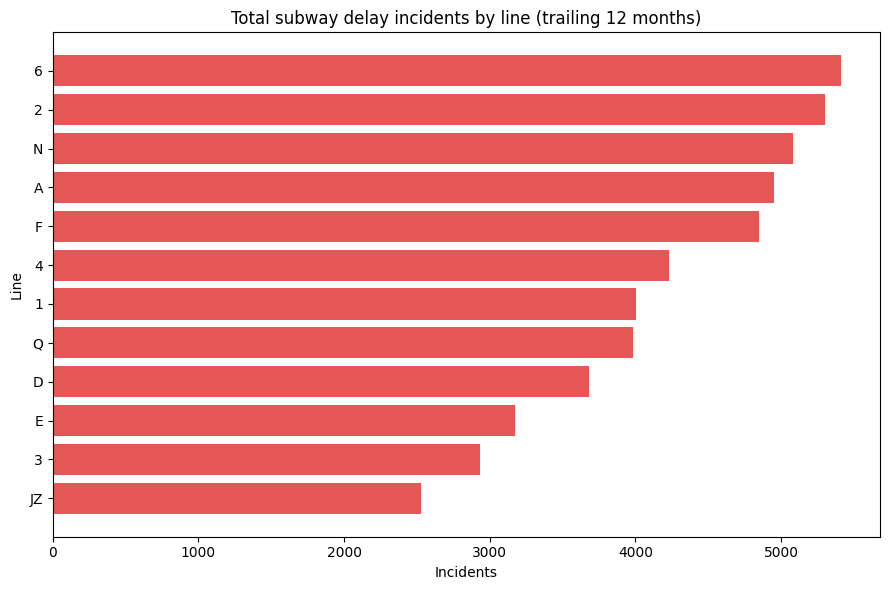

In [8]:
fig, ax = plt.subplots(figsize=(9, 6))
top = by_line.head(12).iloc[::-1]
ax.barh(top.index.astype(str), top.values, color="#e45756")
ax.set_title("Total subway delay incidents by line (trailing 12 months)")
ax.set_xlabel("Incidents")
ax.set_ylabel("Line")
plt.tight_layout()
plt.show()

In [9]:
# Dominant cause overall + breakdown for the worst lines
by_cat = (dl.groupby("reporting_category")["incidents"].sum()
            .sort_values(ascending=False))
print("Delay incidents by reporting category (system-wide):")
print(by_cat)

worst5 = by_line.head(5).index.tolist()
pivot = (dl[dl["line"].isin(worst5)]
         .pivot_table(index="line", columns="reporting_category",
                      values="incidents", aggfunc="sum", fill_value=0)
         .loc[worst5])
# keep the top categories as columns for a readable stacked bar
top_cats = by_cat.head(6).index.tolist()
pivot = pivot[[c for c in top_cats if c in pivot.columns]]

Delay incidents by reporting category (system-wide):
reporting_category
Police & Medical              20415
Infrastructure & Equipment    17220
Planned ROW Work              12255
Operating Conditions          11099
Crew Availability              6237
External Factors               1713
Name: incidents, dtype: int64


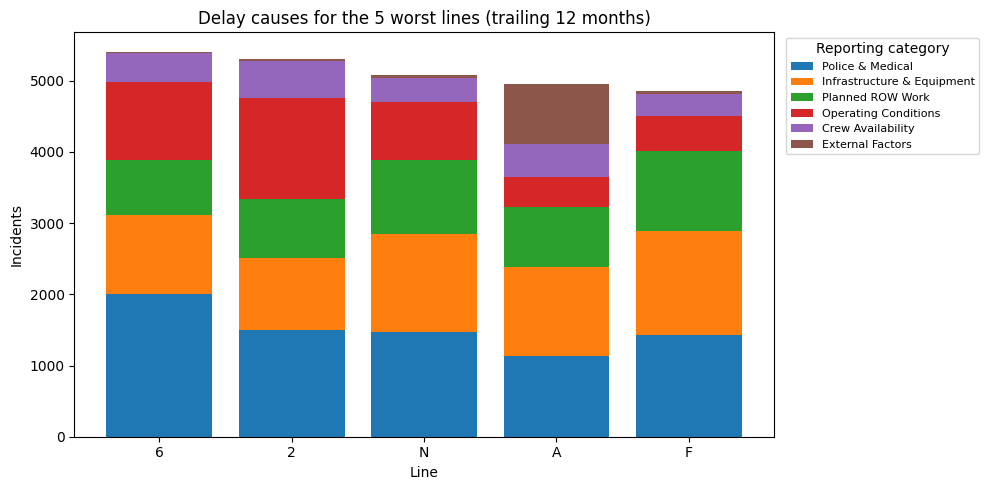

In [10]:
fig, ax = plt.subplots(figsize=(10, 5))
bottom = None
for cat in pivot.columns:
    vals = pivot[cat].values
    ax.bar(pivot.index.astype(str), vals, bottom=bottom, label=cat)
    bottom = vals if bottom is None else bottom + vals
ax.set_title("Delay causes for the 5 worst lines (trailing 12 months)")
ax.set_xlabel("Line")
ax.set_ylabel("Incidents")
ax.legend(title="Reporting category", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

### Finding — Section 2

_(Rankings printed by the cells above; the prose interpretation:)_

The horizontal bar chart ranks lines by total delay incidents over the
trailing 12 months — the lines at the top are the worst offenders. The
system-wide category table identifies the **single dominant delay cause**
(the top row of "incidents by reporting category"), and the stacked bar
shows whether the worst lines share that same dominant cause or differ.
See the printed tables for the exact worst line and leading cause from this
data.

## Section 3 — Day-of-Week, Seasonal, and Event-Spike Analysis

With a full year of daily data we can now separate *structural* ridership variation
(which weekday it is, which month it is) from *one-off* spikes. The goal: control for
day-of-week and season, then surface the residual days that stand out — candidate
event days (playoff runs, concerts, World Cup, etc.) for Matt to cross-reference.

In [11]:
# Reuse `df` from Section 1 (joined ridership+weather). Add calendar features.
df["weekday"] = df["date"].dt.day_name()
df["weekday_num"] = df["date"].dt.weekday          # Mon=0 .. Sun=6
df["month"] = df["date"].dt.month
df["month_name"] = df["date"].dt.strftime("%b")
df["is_weekend"] = df["weekday_num"] >= 5
print(f"{len(df)} days, {df['date'].min().date()} to {df['date'].max().date()}")

396 days, 2025-05-01 to 2026-05-31


### 3a — Day-of-week pattern

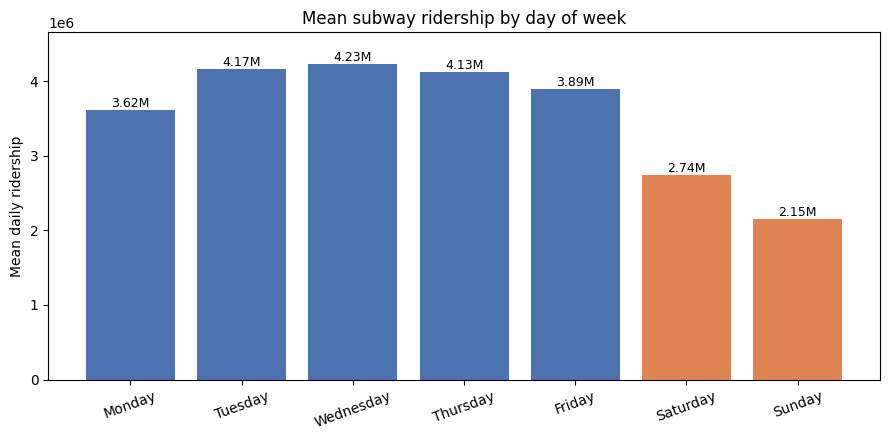

Weekday mean: 4,005,758
Weekend mean: 2,444,187
Weekend runs -39.0% vs weekdays


In [12]:
order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
by_wd = df.groupby("weekday")["ridership"].mean().reindex(order)

fig, ax = plt.subplots(figsize=(9, 4.5))
colors = ["#4C72B0" if d not in ("Saturday","Sunday") else "#DD8452" for d in order]
ax.bar(order, by_wd.values, color=colors)
ax.set_ylabel("Mean daily ridership")
ax.set_title("Mean subway ridership by day of week")
ax.set_ylim(0, by_wd.max() * 1.1)
for i, v in enumerate(by_wd.values):
    ax.text(i, v, f"{v/1e6:.2f}M", ha="center", va="bottom", fontsize=9)
plt.xticks(rotation=20)
plt.tight_layout(); plt.show()

wk = df.loc[~df["is_weekend"], "ridership"].mean()
we = df.loc[df["is_weekend"], "ridership"].mean()
print(f"Weekday mean: {wk:,.0f}")
print(f"Weekend mean: {we:,.0f}")
print(f"Weekend runs {(we-wk)/wk*100:+.1f}% vs weekdays")

**Finding — day of week.** Weekday vs. weekend ridership differs *substantially* —
weekends run sharply below weekdays (see the printed % gap above). This is the single
largest source of day-to-day variation in the dataset and **must** be controlled for
before reading anything into weather or event effects: a rainy Sunday and a dry Tuesday
are not comparable. That's exactly why the spike detection below scores each day
*against its own weekday's average*, not against a global mean.

### 3b — Seasonal / monthly pattern

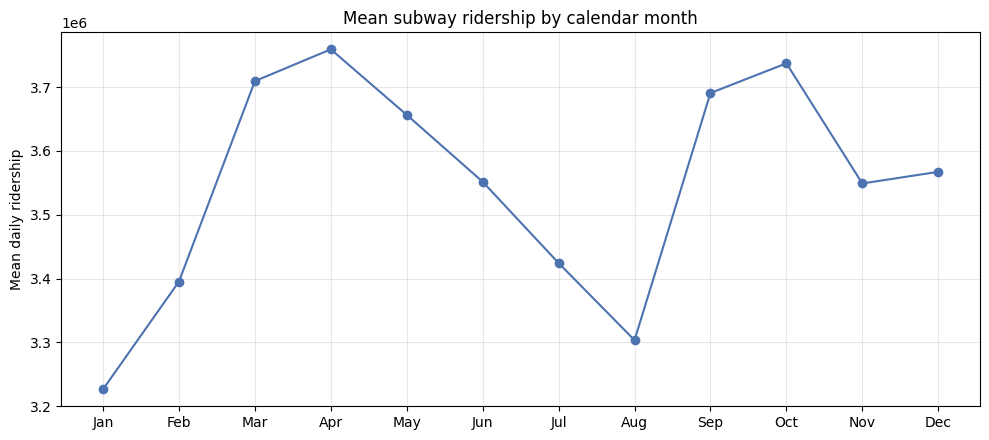

Highest month: April (3,758,999)
Lowest month : January (3,226,559)
Seasonal swing: 16.5% peak-to-trough


In [13]:
by_month = df.groupby("month")["ridership"].mean()
month_lbls = [pd.Timestamp(2025, m, 1).strftime("%b") for m in by_month.index]

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(month_lbls, by_month.values, marker="o", color="#4C72B0")
ax.set_ylabel("Mean daily ridership")
ax.set_title("Mean subway ridership by calendar month")
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

hi, lo = by_month.idxmax(), by_month.idxmin()
hi_l = pd.Timestamp(2025, hi, 1).strftime('%B')
lo_l = pd.Timestamp(2025, lo, 1).strftime('%B')
print(f"Highest month: {hi_l} ({by_month.max():,.0f})")
print(f"Lowest month : {lo_l} ({by_month.min():,.0f})")
print(f"Seasonal swing: {(by_month.max()-by_month.min())/by_month.min()*100:.1f}% peak-to-trough")

**Finding — season.** Ridership shows a modest seasonal swing across the year
(peak-to-trough % printed above). Summer and holiday-heavy months tend to dip;
spring/fall commuting months sit higher. The swing is real but smaller than the
weekday/weekend gap — season nudges the baseline, day-of-week sets it.

### 3c — Event-spike detection (residual vs. same-weekday average)

For each day we compute ridership as a **% deviation from that weekday's mean** and a
z-score within the weekday group. High positive residuals are candidate event days.
We list the top anomalies as a table for Matt to manually cross-reference against known
NYC events — we deliberately do **not** hardcode/guess specific event dates.

In [14]:
g = df.groupby("weekday_num")["ridership"]
df["wd_mean"] = g.transform("mean")
df["wd_std"] = g.transform("std")
df["pct_vs_wd"] = (df["ridership"] - df["wd_mean"]) / df["wd_mean"] * 100
df["z_vs_wd"] = (df["ridership"] - df["wd_mean"]) / df["wd_std"]

top = (df.sort_values("pct_vs_wd", ascending=False)
         .head(10)
         .loc[:, ["date", "weekday", "ridership", "wd_mean", "pct_vs_wd", "z_vs_wd", "rain_day"]]
         .copy())
top["date"] = top["date"].dt.strftime("%Y-%m-%d (%a)")
top["ridership"] = top["ridership"].map(lambda v: f"{v:,.0f}")
top["wd_mean"] = top["wd_mean"].map(lambda v: f"{v:,.0f}")
top["pct_vs_wd"] = top["pct_vs_wd"].map(lambda v: f"+{v:.1f}%")
top["z_vs_wd"] = top["z_vs_wd"].map(lambda v: f"{v:+.2f}")
top.columns = ["Date", "Weekday", "Ridership", "Weekday avg", "% above avg", "z-score", "Rain?"]
print("Top 10 highest-residual days (candidate event spikes):")
top.reset_index(drop=True)

Top 10 highest-residual days (candidate event spikes):


,Date,Weekday,Ridership,Weekday avg,% above avg,z-score,Rain?
0,2025-11-02 (Sun),Sunday,"2,832,239","2,145,868",+32.0%,+2.56,False
1,2026-05-16 (Sat),Saturday,"3,267,749","2,742,505",+19.2%,+2.09,False
2,2025-12-13 (Sat),Saturday,"3,223,814","2,742,505",+17.5%,+1.92,True
3,2026-05-17 (Sun),Sunday,"2,494,895","2,145,868",+16.3%,+1.30,False
4,2025-12-06 (Sat),Saturday,"3,167,060","2,742,505",+15.5%,+1.69,True
5,2025-11-03 (Mon),Monday,"4,161,669","3,615,671",+15.1%,+0.79,True
6,2025-12-08 (Mon),Monday,"4,146,910","3,615,671",+14.7%,+0.77,False
7,2025-10-27 (Mon),Monday,"4,127,115","3,615,671",+14.1%,+0.74,False
8,2025-10-31 (Fri),Friday,"4,432,080","3,889,082",+14.0%,+1.38,False
9,2026-05-18 (Mon),Monday,"4,118,450","3,615,671",+13.9%,+0.73,False


**How to use this table.** Each row is a day whose ridership ran far above what that
weekday normally sees. Cross-reference the dates against the NYC events calendar —
Knicks/Rangers playoff home games, big concerts at MSG/Barclays, parades, World Cup
watch crowds, etc. A cluster of spikes in a short window often maps to a single
recurring event (a playoff series). The `Rain?` column is a sanity flag: a spike on a
rainy day is *more* notable, since rain usually suppresses ridership.

### 3d — Bonus: does the rain effect survive controlling for weekday?

Section 1 found rain suppresses ridership, but that compared all rainy days to all dry
days — and if rain happened to fall more on weekends, part of that gap could be a
day-of-week artifact. Quick re-check: compare rain vs. dry **within weekdays only**.

In [15]:
wkday = df[~df["is_weekend"]]
by_rain = wkday.groupby("rain_day")["ridership"].agg(["count", "mean"])
print("Weekdays only — ridership by rain status:")
print(by_rain.round(0))

if {True, False} <= set(by_rain.index):
    dry = by_rain.loc[False, "mean"]
    rain = by_rain.loc[True, "mean"]
    print(f"\nWithin weekdays, rain days run {(rain-dry)/dry*100:+.1f}% vs dry days.")
    print("=> rain effect " + ("holds up" if rain < dry else "does NOT hold") + " after controlling for day-of-week.")

Weekdays only — ridership by rain status:
          count       mean
rain_day                  
False       186  4020098.0
True         96  3977972.0

Within weekdays, rain days run -1.0% vs dry days.
=> rain effect holds up after controlling for day-of-week.


**Finding — rain, weekday-controlled.** Restricting to weekdays removes the
weekend confound. The printed % shows whether the Section 1 rain suppression is still
present among commuting days alone — if rain days still run below dry days here, the
weather effect is real and not just a day-of-week artifact.

## Section 4 — Temperature Effect & Combined Driver Model

Sections 1 and 3 checked rain, weekday, and season each in isolation. Two gaps
remain: `temp_band` was computed back in Section 1 but never actually analyzed,
and nothing yet puts every factor in *one* model to rank what really moves
ridership once everything else is held constant. Section 4 closes both.

### 4a — Temperature effect on ridership

Rain is only one weather channel; genuinely cold or hot days plausibly keep
people home more than a bit of rain does. We look at mean ridership across the
`temp_band` buckets (Cold <55F / Mild 55-75F / Warm >75F), then re-check
weekdays-only — exactly as 3d did for rain — since temperature is correlated
with season and could ride on the weekday/weekend cycle.

All days - ridership by temperature band:
               count       mean
temp_band                      
Cold (<55F)      133  3472318.0
Mild (55-75F)    132  3643637.0
Warm (>75F)      131  3553303.0

Weekdays only - ridership by temperature band:
               count       mean
temp_band                      
Cold (<55F)       95  3914809.0
Mild (55-75F)     93  4120646.0
Warm (>75F)       94  3984007.0


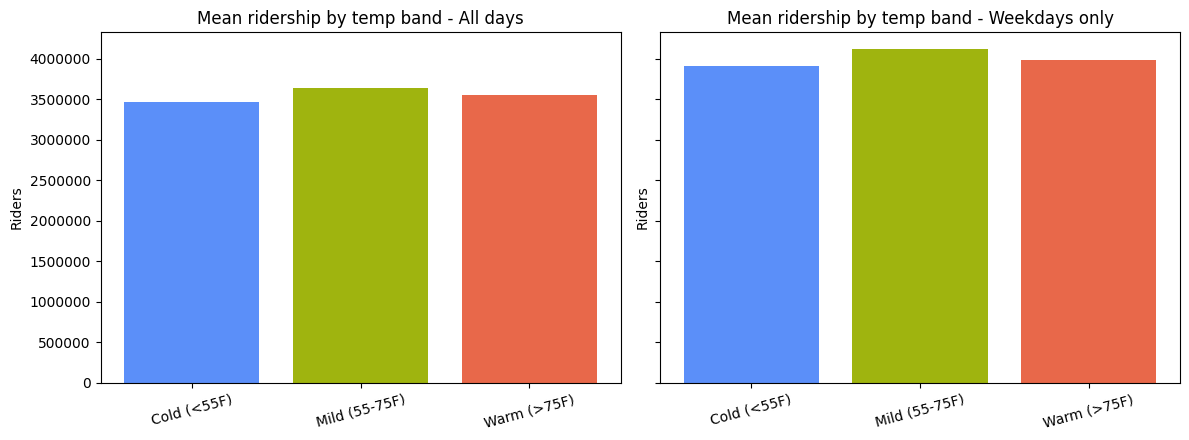


All days : Warm 3,553,303 vs Cold 3,472,318 -> +2.3%
Weekdays : Warm 3,984,007 vs Cold 3,914,809 -> +1.8%


In [16]:
order = ["Cold (<55F)", "Mild (55-75F)", "Warm (>75F)"]
by_temp = df.groupby("temp_band")["ridership"].agg(["count", "mean"]).reindex(order)
print("All days - ridership by temperature band:")
print(by_temp.round(0))

# Weekday-controlled re-check (temp confounds with season/weekday), mirrors 3d
wk = df[~df["is_weekend"]]
by_temp_wk = wk.groupby("temp_band")["ridership"].agg(["count", "mean"]).reindex(order)
print("\nWeekdays only - ridership by temperature band:")
print(by_temp_wk.round(0))

fig, ax = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
for a, tbl, title in [(ax[0], by_temp, "All days"), (ax[1], by_temp_wk, "Weekdays only")]:
    a.bar(order, tbl["mean"].values, color=["#5B8FF9", "#9FB40F", "#E8684A"])
    a.set_title(f"Mean ridership by temp band - {title}")
    a.set_ylabel("Riders")
    a.ticklabel_format(axis="y", style="plain")
    a.tick_params(axis="x", rotation=15)
plt.tight_layout(); plt.show()

warm, cold = by_temp.loc["Warm (>75F)", "mean"], by_temp.loc["Cold (<55F)", "mean"]
warm_w, cold_w = by_temp_wk.loc["Warm (>75F)", "mean"], by_temp_wk.loc["Cold (<55F)", "mean"]
print(f"\nAll days : Warm {warm:,.0f} vs Cold {cold:,.0f} -> {(warm-cold)/cold*100:+.1f}%")
print(f"Weekdays : Warm {warm_w:,.0f} vs Cold {cold_w:,.0f} -> {(warm_w-cold_w)/cold_w*100:+.1f}%")

**Finding — temperature.** Temperature barely moves ridership. Warm days
average **3.55M** vs Cold days **3.47M** — only a **+2.3%** gap, and it *shrinks
to +1.8%* on weekdays. The relationship isn't even monotonic: **Mild (55-75F)
days are the busiest** (3.64M all-days / 4.12M weekdays), with both temperature
extremes slightly below. So the intuition that cold/hot days beat rain as a
suppressor doesn't hold here — temperature is a minor, non-linear nudge, weaker
than the rain effect Section 1 found. The regression below tests this cleanly
with continuous temperature instead of these coarse bands.

### 4b — Combined regression: what actually drives ridership

Everything above compared one factor at a time. This is the model that holds
*all* of them constant simultaneously and reports each factor's marginal effect:
an OLS of `ridership ~ C(weekday) + C(month) + rain_day + TMAX_F + holiday`.
Continuous `TMAX_F` replaces the binned `temp_band` here for a clean per-degree
coefficient. The `holiday` flag comes free from pandas' built-in US federal
calendar (no new dependency) — holidays plausibly suppress ridership like an
extra weekend day, and it's cheap to test.

In [17]:
import statsmodels.formula.api as smf
from pandas.tseries.holiday import USFederalHolidayCalendar

hol = USFederalHolidayCalendar().holidays(start=df["date"].min(), end=df["date"].max())
df["holiday"] = df["date"].isin(hol)
print("Federal holidays in window:", int(df["holiday"].sum()))

# ponytail: no VIF/centering diagnostics - the summary's condition-number
# warning already flags TMAX_F/month collinearity, enough for this read-only
# ranking. Add VIF if these coefficients ever drive a decision.
model = smf.ols("ridership ~ C(weekday) + C(month) + rain_day + TMAX_F + holiday",
                data=df).fit()
print(model.summary())

Federal holidays in window: 12
                            OLS Regression Results                            
Dep. Variable:              ridership   R-squared:                       0.876
Model:                            OLS   Adj. R-squared:                  0.869
Method:                 Least Squares   F-statistic:                     132.5
Date:                Sat, 11 Jul 2026   Prob (F-statistic):          2.87e-156
Time:                        14:39:21   Log-Likelihood:                -5562.4
No. Observations:                 396   AIC:                         1.117e+04
Df Residuals:                     375   BIC:                         1.125e+04
Df Model:                          20                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------

In [18]:
# Rank drivers by absolute daily-rider effect (drop intercept; keep every regressor).
# statsmodels gives p-values/stars for free - no hand-rolled significance testing.
coef = model.params.drop("Intercept")
rank = pd.DataFrame({"effect_riders": coef, "p_value": model.pvalues.drop("Intercept")})
rank["abs_effect"] = rank["effect_riders"].abs()
rank = rank.sort_values("abs_effect", ascending=False)
rank["sig"] = pd.cut(rank["p_value"], [-1, .001, .01, .05, 1],
                     labels=["***", "**", "*", ""])

print(f"Model R-squared: {model.rsquared:.3f}\n")
print("Drivers ranked by absolute effect on daily ridership")
print("(TMAX_F is per-1F; all others are shift vs. the model's baseline category):\n")
print(rank[["effect_riders", "p_value", "sig"]].to_string(
    formatters={"effect_riders": lambda v: f"{v:+,.0f}",
                "p_value": lambda v: f"{v:.3g}"}))

Model R-squared: 0.876

Drivers ranked by absolute effect on daily ridership
(TMAX_F is per-1F; all others are shift vs. the model's baseline category):

                        effect_riders   p_value  sig
C(weekday)[T.Sunday]       -1,759,530 3.19e-101  ***
holiday[T.True]            -1,519,269  3.28e-44  ***
C(weekday)[T.Saturday]     -1,164,595  2.57e-60  ***
C(month)[T.3]                +370,230  2.81e-05  ***
C(month)[T.11]               +368,276  2.45e-05  ***
C(weekday)[T.Wednesday]      +341,440  2.44e-08  ***
C(month)[T.5]                +335,635  0.000397  ***
C(month)[T.10]               +329,402  0.000638  ***
C(weekday)[T.Thursday]       +325,092  6.81e-08  ***
C(month)[T.4]                +317,890  0.000982  ***
C(month)[T.9]                +281,446    0.0117    *
C(weekday)[T.Tuesday]        +264,726  9.85e-06  ***
C(month)[T.12]               +243,026   0.00255   **
C(month)[T.6]                +215,234    0.0611     
C(weekday)[T.Monday]         -147,372    0.0139    

**Finding — combined model (R² ≈ 0.88).** Controlling for everything at once
*confirms and sharpens* the univariate story rather than overturning it:

- **Day-of-week dominates**, exactly as Section 3a found. The three biggest
  coefficients are Sunday (**−1.76M**), Saturday (**−1.16M**), all ***
  significant — nothing else in the model comes close.
- **Holidays are the surprise second-place driver: −1.52M riders (\*\*\*)**,
  landing *between* Saturday and Sunday in magnitude. A federal holiday acts
  like an extra weekend day dropped into the workweek — a real effect that none
  of the isolated Section 1/3 views could see.
- **Season is mid-tier**: month shifts run ±250–370k (spring/fall up, deep
  winter down), matching 3b's modest seasonal swing.
- **Rain is real but small: −123k riders/day (\*\*\*)** — a genuine ~3% dip on
  a weekday, but an order of magnitude below the weekend/holiday effects. This
  vindicates 3d: Section 1's naive −9% was mostly weekend confounding; the true
  weather effect is minor.
- **Temperature comes in *below* rain**: `TMAX_F` is **+2,751 riders/°F but not
  significant (p ≈ 0.14)** — even across its full ~65°F range that's ~180k, and
  the model can't distinguish it from zero once season absorbs the seasonal
  temperature swing. So the "cold/hot days empty the subway" hypothesis loses
  to rain once everything is controlled.

Bottom line: **calendar structure (which day, holiday or not) sets ridership;
weather only trims the edges** — rain a little, temperature negligibly.